In [1]:
import os 
import sys
sys.path.append("../")

import torch
import numpy as np

import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib as mpl
from matplotlib.patches import Patch

from vi_rnn.utils import *
from vi_rnn.load_data import * 
from vi_rnn.evaluation import * 
from vi_rnn.saving import load_model

import pickle
import pandas as pd 

from evaluation.calc_stats import * 
from scipy.stats import pearsonr 

import warnings
warnings.filterwarnings("ignore")
torch.set_warn_always(False)

torch.manual_seed(0)
np.random.seed(0)

%matplotlib inline
plt.rcParams['font.family'] = 'DeJavu Serif'
plt.rcParams['font.serif'] = ['Times New Roman']
plt.rcParams['text.usetex'] = False

### Load spikes and neuromodulation signal

In [2]:
data_dir_nk339 = '../data/nk339/' 
config = {
    'data_dir': data_dir_nk339, 
    'model_dir': "../models/all/",
    "stat_dir": "../results/model_evals/",
    'sampling_rate': 30_000, # Hz
    'bin_size': 0.05,
    'fr_threshold': 0.5,
    'threshold_neurons': True,
    'z_score_neuromod': False,
    'min_max_norm_neuromod': True,
    'z_score_neurons': True,
    'deconvolve': False,
    'convolve_spikes': True,
    'normalize_neuromod': True,
    'center_neuromod': False,
    'center_data': True,
    'load_physiology': False,
    'shuffle': False,
    'dales_law': True
}

In [3]:
spikes, spike_counts, neuromod_activity, trials_df, cell_types = load_data(config)
# split dataset into train and test samples based on amount of data available 
data_dur = spike_counts.shape[1] * config['bin_size']
# first find when the last trial is. Last trials is always odor, which lasts 120 seconds 
last_trial_timestamp = trials_df['cs'].max() + 120
baseline_dur = data_dur - last_trial_timestamp
# split into 75% train and 25% test samples. The tail end of the data will be used for training
config['baseline_test_start'] = int(data_dur - baseline_dur)
config['baseline_train_start'] = int(data_dur - 0.75 * baseline_dur)

config['baseline_test_end'] = config['baseline_train_start']
config['baseline_train_end'] = int(data_dur)
print(config['baseline_test_end'] - config['baseline_test_start'])
# prepare dataset 
x, s, stim_arr, seq_periods, white_noise_trial_avgs, airpuff_trial_avgs, reward_trial_avgs = prepare_dataset(spike_counts, 
                                            neuromod_activity,
                                            trials_df, 
                                            config,
                                            test=True)
x_train, s_train, _, _, _, _, _ = prepare_dataset(spike_counts,
                                            neuromod_activity,
                                            trials_df,
                                            config,
                                            test=False)

t_end = 5622
123 neurons removed
cell type: [ 1  1 -1  1 -1  1  1  1 -1  1  1  1  1  1 -1  1  1  1  1  1  1  1 -1  1
  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1
  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1 -1  1  1  1  1
 -1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1 -1  1  1  1  1  1
  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1 -1  1  1  1  1  1 -1  1  1
  1 -1  1  1 -1  1  1  1 -1  1  1  1  1  1  1  1  1 -1  1  1  1  1  1  1
  1  1  1  1  1  1  1  1 -1 -1  1  1  1  1  1 -1  1  1  1 -1  1 -1 -1 -1
 -1  1 -1 -1  1 -1  1  1  1  1  1  1  1  1  1  1]
length of downsampled signal: 112838
length of original signal: 5641891
False
False
288
(5760,) (19950,)
Shape of data samples: (184, 19950), (19950,)
(17340,) (35830,)
Shape of data samples: (184, 35830), (35830,)


In [13]:
x_train.shape

torch.Size([184, 35830])

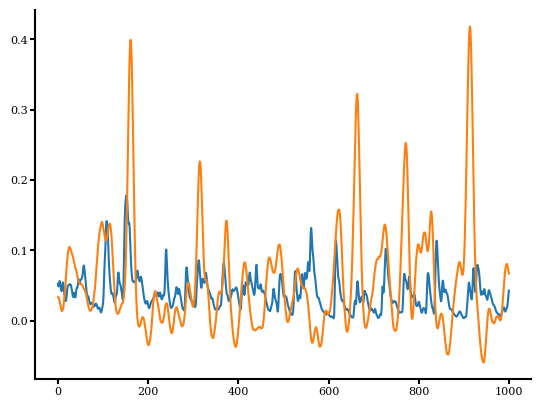

In [14]:
plt.plot(s_train[:1000].T)
plt.plot(x_train.mean(axis=0)[:1000].T)

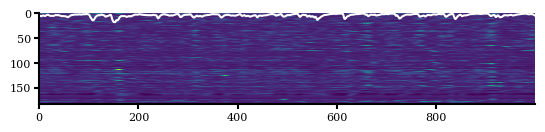

In [5]:
plt.imshow(x_train[:,:1000])
plt.plot((s_train[:1000]*100).T,color='w')

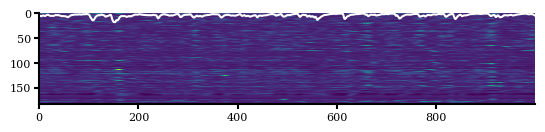

In [6]:
plt.imshow(x_train[:,:1000])
plt.plot((s_train[:1000]*100).T,color='w')

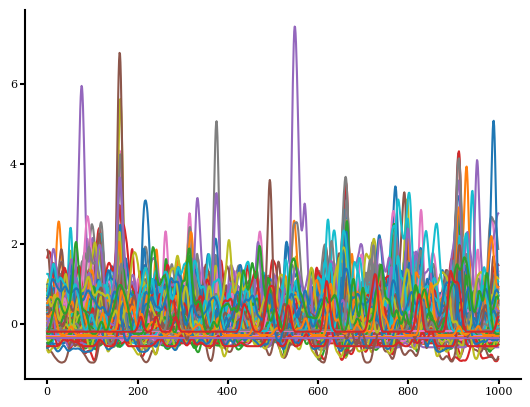

In [7]:
plt.plot(x_train[:,:1000].T);

In [8]:
s

array([0.05619755, 0.05730694, 0.05957279, ..., 0.08814015, 0.07936069,
       0.07300373])

Text(0.5, 1.0, 'Normalized Neuromodulator signal')

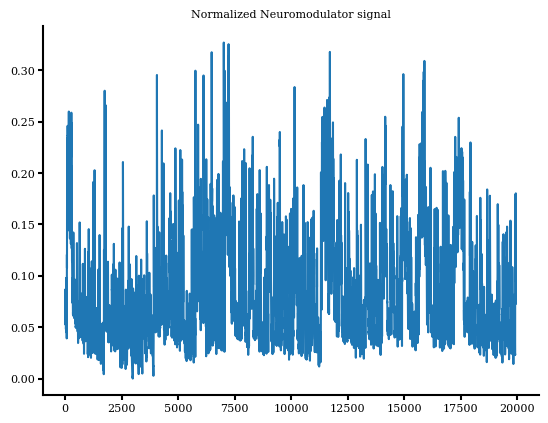

In [9]:
plt.plot(s)
plt.title('Normalized Neuromodulator signal')

In [10]:
x = torch.from_numpy(x).to(torch.float32) 
x_train = torch.from_numpy(x_train).to(torch.float32)
s = torch.from_numpy(s).to(torch.float32)
stim_arr = torch.from_numpy(stim_arr).to(torch.float32) 
white_noise_trial_avgs = torch.from_numpy(white_noise_trial_avgs).to(torch.float32)
airpuff_trial_avgs = torch.from_numpy(airpuff_trial_avgs).to(torch.float32)
reward_trial_avgs = torch.from_numpy(reward_trial_avgs).to(torch.float32)

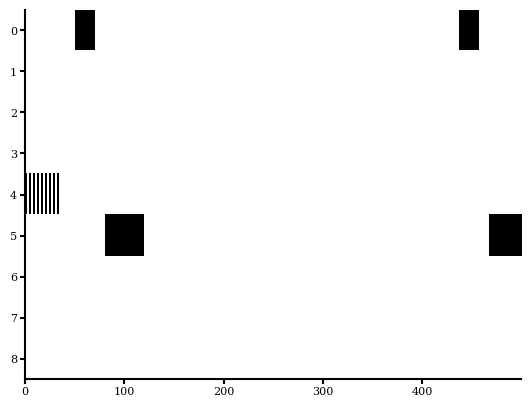

In [11]:
plt.imshow(stim_arr[:,7000:7500], aspect='auto', cmap='gray_r')

### Compute statistics between train and test data samples

n_samples = 3000
# divide into samples of length n_samples 
kl_divs_data = []
was_dists_data = [] 
sliced_wasserstein_data = [] 
mres_data = [] 

x_test = x[:,:n_samples]
for i in range(1, 6):
    x_train_slice = x_train[:, (i-1)*n_samples : i*n_samples]
    kl_div = compute_KL_divergence(x_train_slice.unsqueeze(0), x_test.unsqueeze(0), n_samples=n_samples)
    was_dist = compute_wasserstein(x_test.T.numpy(), x_train_slice.T.numpy(), n_samples=n_samples)
    mre = mean_rate(x_test.numpy(), x_train_slice.numpy()) 
    print(kl_div, was_dist, mre)
    kl_divs_data.append(kl_div) 
    was_dists_data.append(was_dist) 
    mres_data.append(mre) 

### 2. Baseline evaluation

### Load models

In [24]:
model_config = {
    "dataset": "nk339_mPFC",
    "seed": 4107,#8495,#8912,#7366,#7756,#1735,#1387,#6834,#9971,#1594,
    "rank": 12,
    "activation": "relu", 
    "stim": True, 
    "bin_size": 0.05, 
    "dales_law": False  
}

neuromodulation_mechanisms = ["None", "postsynaptic", "presynaptic", "additive", "rank"]
neuromodulation_mechanisms = ["postsynaptic"]

models = {}

for neuromodulation in neuromodulation_mechanisms:
    filepath = os.path.join(config['model_dir'], f'{model_config["dataset"]}_{neuromodulation}_rank_{model_config["rank"]}_activation_{model_config["activation"]}_seed_{model_config["seed"]}_stim_{model_config["stim"]}_binsize_{str(model_config["bin_size"]).replace(".", "_")}_daleslaw_{model_config["dales_law"]}')
    vae, params, task_params, training_params = load_model(filepath)
    models[neuromodulation] = vae

dict_keys(['dim_x', 'dim_z', 'dim_u', 'dim_N', 'dim_s', 'enc_architecture', 'enc_params', 'rnn_params', 'causal', 'cell_types', 'rnn_architecture'])
184 184
Neuromodulation type: postsynaptic
using ReLU activation
using uniform init
weight scaler 0.4
184
using acausal constant padding


In [25]:

def generate_trajectory(x_test, s_test, stim, vae, neuromod, noise_scale=1.0, sim_s=False,initial_state="posterior_sample", k=1):
    """
    Args:
        x_test (torch.tensor; neurons x time): Neural activity 
        s_test (torch.tensor; time); Neuromodulation signal
        stim (torch.tensor; number of stimuli x time): Stimuli traces
        vae (VAE): the model 
        neuromod: the neuromodulation type
        noise_scale: How much noise to add to the trajectories
    Returns:
        obs (torch.tensor; neurons x T): Generated trajectory
    """
        
    T = s_test.shape[0]
    s = s_test.view(1, 1, -1)
    if stim is not None:
        u = stim.unsqueeze(0) 
    
    # Retrieve initial latent state by projecting x onto z
    #z_hat, _, _, _ = vae.encoder(x_test.unsqueeze(0))

    # actually better to sample initial state from the posterior
    prior_mean = vae.rnn.get_initial_state(u[:, :, 0],stim[:,:1]).unsqueeze(-1)
    prior_mean = prior_mean.expand(*prior_mean.shape[:2], k)
    if initial_state=="prior_sample":
        z0 = prior_mean
    else:
        eff_var_x = torch.clip(vae.rnn.var_embed_x(vae.rnn.R_x), 1e-8)
        eff_var_prior_t0_chol = chol_cov_embed(vae.rnn.R_z_t0)

        # Get the observation weights and bias
        vae.rnn.params['readout_from']='currents'
        if vae.rnn.params["readout_from"] == "currents":
            m = vae.rnn.transition.m
            #print(m.shape)
            #print( vae.rnn.observation.B.unsqueeze(-1).shape)
            B = vae.rnn.observation.B@ m[:vae.dim_x]
            B = B.T
        elif vae.rnn.params["readout_from"] == "z_and_v":
            B = vae.rnn.observation.B[vae.dim_u:]
            Bu = vae.rnn.observation.B[:vae.dim_u]
        else:
            B = vae.rnn.observation.B

        Obs_bias = vae.rnn.observation.Bias.view(1, -1, 1)

        # set Kalman update function
        if vae.dim_x < vae.dim_z * 4:
            kalman_update = Kalman_update_highD
        else:
            kalman_update = Kalman_update_lowD
        alpha, one_min_alpha, Kalman_gain, var_Q_cholesky = kalman_update(
            eff_var_prior_t0_chol, B, eff_var_x
        )
        #print("x shape ", x.shape)
        mean_Q = torch.einsum(
            "zs,BsK->BzK", one_min_alpha, prior_mean
        ) + torch.einsum(
            "zx,BxK->BzK", Kalman_gain, x_test[:, 0].unsqueeze(0).unsqueeze(-1) - Obs_bias
        )
        #print(mean_Q.shape)
        #print(var_Q_cholesky.shape)
        if initial_state == "posterior_sample":
            Q_dist = torch.distributions.MultivariateNormal(
                loc=mean_Q.permute(0, 2, 1), scale_tril=var_Q_cholesky
            )
            z0 = Q_dist.sample().permute(0, 2, 1)

        elif initial_state == "posterior_mean":
            z0 = mean_Q
    z_hat = z0
        #print(z_hat.shape)
        #z0 = z_hat[:, :, 0].squeeze()
    if stim is not None:
        sim_v = True
    else:
        stim=None 
        sim_v = False

    if neuromod is None: 
        if stim is None:
            Z = vae.rnn.get_latent_time_series(time_steps=T, cut_off=0, z0=z0, u=stim, noise_scale=noise_scale, sim_v=sim_v, sim_s=False)
            obs = vae.rnn.get_observation(Z, noise_scale=0)[0, :, :, 0]
        else:   
            Z, V = vae.rnn.get_latent_time_series(time_steps=T, cut_off=0, z0=z0, u=u, noise_scale=noise_scale, sim_v=sim_v, sim_s=False)
            obs = vae.rnn.get_observation(Z, v=V, noise_scale=0)[0, :, :, 0]
    elif 'additive' in neuromod or sim_s==True:
        if stim is None:
            Z, S = vae.rnn.get_latent_time_series(time_steps=T, cut_off=0, z0=z0, s=s, noise_scale=noise_scale, sim_v=sim_v, sim_s=True)
            obs = vae.rnn.get_observation(Z, s=S, noise_scale=0)[0, :, :, 0]
        else:
            Z, V, S = vae.rnn.get_latent_time_series(time_steps=T, cut_off=0, z0=z0, u=u, s=s, noise_scale=noise_scale, sim_v=sim_v, sim_s=True)
            obs = vae.rnn.get_observation(Z, s=S, v=V, noise_scale=0)[0, :, :, 0]
    else: 
        if stim is None:
            Z = vae.rnn.get_latent_time_series(time_steps=T, cut_off=0, z0=z0, u=stim, s=s, noise_scale=noise_scale, sim_v=sim_v, sim_s = False)
            obs = vae.rnn.get_observation(Z, noise_scale=0)[0, :, :, 0]
        else:
            Z, V = vae.rnn.get_latent_time_series(time_steps=T, cut_off=0, z0=z0, u=stim if stim is None else u, s=s, noise_scale=noise_scale, sim_v=sim_v, sim_s = False)
            obs = vae.rnn.get_observation(Z, v=V, noise_scale=0)[0, :, :, 0]
    if sim_s: 
        return (z_hat.detach(), S.detach(), obs.detach())
    return (z_hat.detach(), obs.detach()) 

In [26]:
#stim = torch.zeros((0, x_.shape[1]))
stim = stim_arr
trajs = []
num_trajs = 1
t_start, t_end = config['baseline_test_start'], config['baseline_test_start'] + 600

x_, s_ = get_block(spike_counts, neuromod_activity, t_start, t_end - t_start, config['bin_size'])

s_ = (s_ - s_train.min()) / (s_train.max() - s_train.min())
trajs_gen = {mechanism: [] for mechanism in neuromodulation_mechanisms}

for mechanism in neuromodulation_mechanisms:
    for i in range(num_trajs):
        traj = generate_trajectory(torch.from_numpy(x_).to(torch.float32), 
                                torch.from_numpy(s_).to(torch.float32), 
                                stim, 
                                models[mechanism], 
                                mechanism if mechanism is not 'None' else None,
                                initial_state="prior_sample")[1].detach()
        
        trajs_gen[mechanism].append(traj)


In [27]:
traj.shape

torch.Size([184, 12000])

In [28]:
x_.shape

(184, 12000)

(-1.0, 6.0)

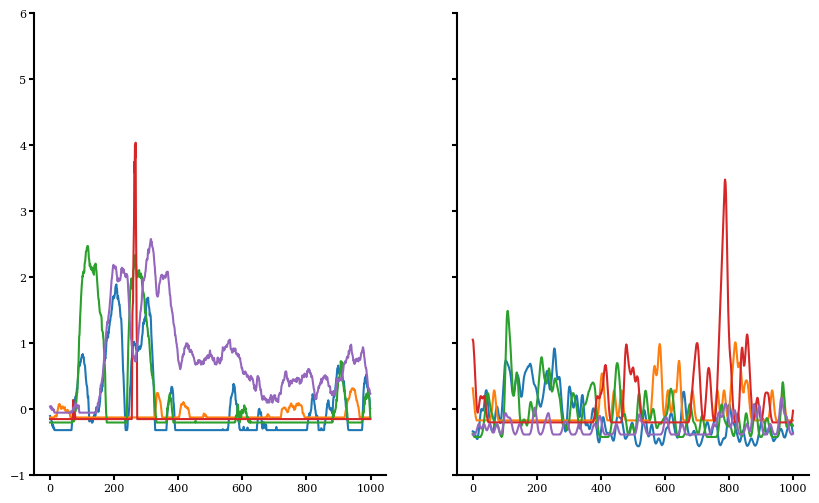

In [32]:
fig, ax = plt.subplots(1,2,figsize=(10,6), sharey=True)
neui_inds = np.random.choice(traj.shape[0], size=5, replace=False)
ax[0].plot(traj[neui_inds,:1000].T)
ax[1].plot(x_[neui_inds,:1000].T);
ax[1].set_ylim([-1,6])

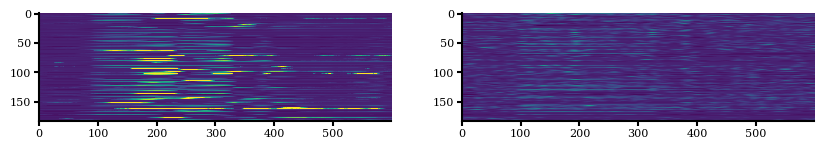

In [33]:
fig, ax = plt.subplots(1,2,figsize=(10,6))
vmax = 6
ax[0].imshow(traj[:,:600], vmax=vmax)
ax[1].imshow(x_[:,:600], vmax=vmax);

In [60]:
vae.dim_N

184

In [61]:
def plot_bar(stats: np.array, block_idx: int, title, width=0.4):
    means = [stats[model].mean(axis=0)[block_idx] for model in stats.keys()]
    stds = [stats[model].std(axis=0)[block_idx] for model in stats.keys()] 
    std_err = [stds[i] / len(stats[model]) for i, model in enumerate(stats.keys())]

    x = np.arange(len(means))
    fig, ax = plt.subplots(figsize=(10,8))
    ax.bar(x, means, width, yerr=std_err, alpha=0.7, capsize=5)

    for i, cat in enumerate(stats.keys()):
        x_jittered = x[i] + np.random.uniform(-width/4, width/4, stats[cat].shape[0])
        ax.scatter(x_jittered, stats[cat][:, block_idx], s=10)
    ax.set_xticklabels(list(model_mres.keys()))
    ax.tick_params(axis='both', which='major', labelsize=10)
    ax.set_xticks(x)
    ax.set_title(title, fontsize=15)

def plot_group_bar(stats: np.array, title, width=0.1):
    means = {block: [stats[model].mean(axis=0)[block] for model in stats.keys()] for block in range(3)}
    stds = {block: [stats[model].std(axis=0)[block] for model in stats.keys()] for block in range(3)}
    
    x = np.arange(len(list(means.keys())))
    print(len(x))
    fig, ax = plt.subplots(figsize=(10, 8)) 
    for i, group in enumerate(stats.keys()):
        offsets = x - width / 2 + i * width 
        mean_values = [means[block][i] for block in range(len(list(means.keys())))]
        ax.bar(offsets, mean_values, width, label=group, alpha=0.7)

### Compute psth around neuromodulator peaks

In [62]:
def compute_LC_trig_activity(traj, neuromod_val, dur=200): 
    neuromod_zsc = (neuromod_val - neuromod_val.mean()) / neuromod_val.std() 
    # take everything above 2 standard deviations 
    neuromod_peaks = np.where(neuromod_zsc > 2)[0]
    psths_val = np.zeros((len(neuromod_peaks), traj.shape[0], dur))
    nrpn = np.zeros((len(neuromod_peaks), dur))
    for i, peak in enumerate(neuromod_peaks):
        if peak - dur // 2 >= 0 and peak + dur // 2 < traj.shape[1]:
            psths_val[i] = traj[:, peak - dur // 2:peak + dur // 2]
            nrpn[i] = neuromod_val[peak - dur // 2:peak + dur // 2]
    psths_val = psths_val.mean(axis=0)
    # sort by time of peak
    max_indices = np.argmax(psths_val, axis=1)
    psths_sorted = psths_val[np.argsort(max_indices)]
    psths_sorted = (psths_sorted - psths_sorted.mean(axis=1, keepdims=True)) / psths_sorted.std(axis=1, keepdims=True)
    nrpn = nrpn.mean(axis=0)
    return psths_val, psths_sorted, nrpn, max_indices

In [63]:
import matplotlib.gridspec as gridspec
def plot_psths(psths_val, ind_test):
    psths_val = np.nan_to_num(psths_val)
    fig, ax = plt.subplots(figsize=(10, 8))
    gs = gridspec.GridSpec(
        1, 3,
        width_ratios=[20, 1, 1],
        wspace=0.05,
        left=0.05, right=0.95, top=0.95, bottom=0.05
    )

    ax_heatmap = plt.subplot(gs[0])
    im = ax_heatmap.imshow(psths_val, cmap='RdBu_r', vmin=-4, vmax=4, origin='upper', aspect='auto')
    ax_heatmap.set_yticks([])
    #ax.set_yticklabels([])
    ax_heatmap.axis('off')

    ax_cbar = plt.subplot(gs[1])
    plt.colorbar(im, cax=ax_cbar) 

    # mappable = ax.imshow(psths_val, cmap='RdBu_r', vmin=-4, vmax=4)
    # ax.set_ylabel('Neurons')
    ax.set_xlabel('Time')
    # fig.colorbar(mappable, label='intensity', shrink=0.5)
    # ax.set_title('Peak LC triggered neural activity in validation set')
    # fig.savefig('LC_trig_activity.png')
    # Tick bar: custom bar showing marks for specific rows
    ax_bar = plt.subplot(gs[2])
    ax_bar.set_ylim(ax_heatmap.get_ylim()) 
    ax_bar.set_xlim(0, 1)
    ax_bar.axis('off')  # Hide the frame and ticks
    highlight_rows = np.where(cell_types[np.argsort(ind_test)] == -1)
    # Plot tick marks
    for r in highlight_rows:
        ax_bar.plot([0.2, 0.8], [r, r], color='black', lw=2)  # Horizontal ticks

4467 5067


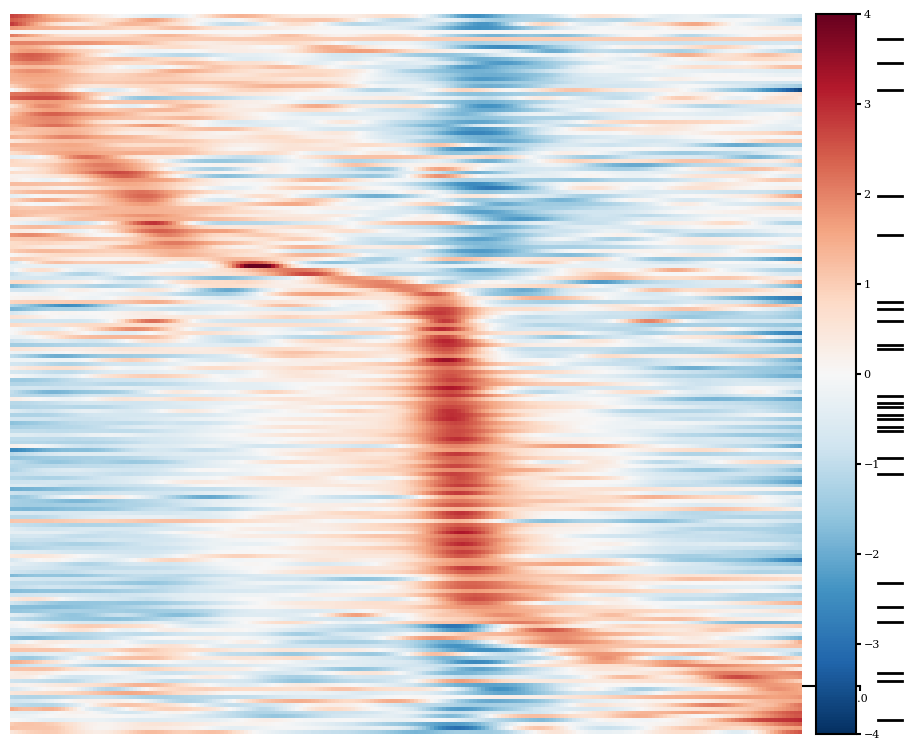

In [64]:
import matplotlib.gridspec as gridspec

t_start, t_end = config['baseline_test_start'], config['baseline_test_start'] + 600
# t_start, t_end = 4_750 - 300, 4_750
# t_start, t_end = odor_blocks[-1][0] - 10, odor_blocks[-1][1] + 10
x_, s_ = get_block(spike_counts, neuromod_activity, t_start, t_end - t_start, config['bin_size'])
print(t_start, t_end)
_, psths_val, nrpn, ind_test = compute_LC_trig_activity(x_, s_, dur=200)
psths_val = np.nan_to_num(psths_val)
plot_psths(psths_val, ind_test)


[]

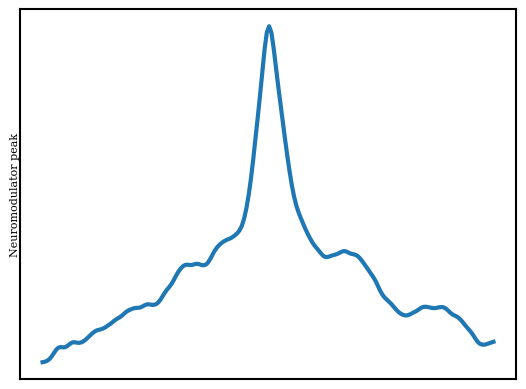

In [65]:
fig, ax = plt.subplots()
ax.plot(nrpn, linewidth=3)
for spine in ax.spines.values():
    spine.set_visible(True)
ax.set_ylabel('Neuromodulator peak')
ax.set_xticks([])
ax.set_yticks([])
# fig.savefig('../../results/figures/nrpn.svg', format='svg')

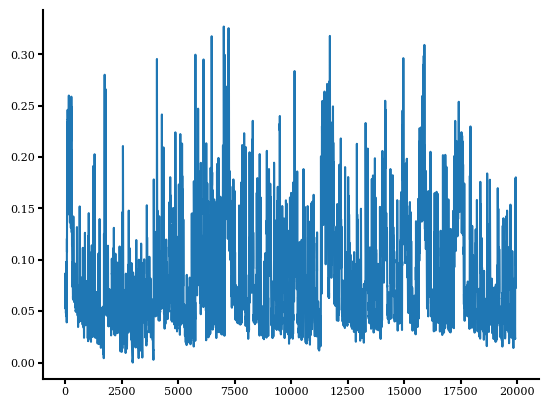

In [66]:
plt.plot(s)

In [67]:
vae.dim_u

9

In [68]:
stim = torch.zeros((0, x_.shape[1]))
stim = stim_arr
trajs = []
num_trajs = 1
s_ = (s_ - s_train.min()) / (s_train.max() - s_train.min())
trajs_gen = {mechanism: [] for mechanism in neuromodulation_mechanisms}

for mechanism in neuromodulation_mechanisms:
    for i in range(num_trajs):
        traj = generate_trajectory(torch.from_numpy(x_).to(torch.float32), 
                                torch.from_numpy(s_).to(torch.float32), 
                                stim, 
                                models[mechanism], 
                                mechanism if mechanism is not 'None' else None,
                                initial_state="prior_sample")[1].detach()
                                
        trajs_gen[mechanism].append(traj)


### Visualize trajectories of inhibitory neurons

In [69]:
def plot_traces(trajs_gen, trajs_test, neurons=None):
    neurons = [132, 10, 20, 55, 84]
    colors = ['#000000', "#a913d6",  "#008080", "#c98510", "#c9081b"]
    num_neurons = len(neurons)
    mechanisms = ['None', 'postsynaptic', 'presynaptic', 'additive', 'rank']
    mechanisms = ['postsynaptic','postsynaptic']
    fig, ax = plt.subplots(num_neurons, len(mechanisms), figsize=(15, 10))

    # identify neurons with the best rs 
    # r_vals = []
    # for i in range(spike_counts.shape[0]):
    #     r_vals.append(r2_score(trial_avgs['postsynaptic_stim'][i].detach().numpy(), trial_avgs['test'][i].detach().numpy()))
    # for mechanism in mechanisms:
    #     trial_avgs[mechanism] = trial_avgs[mechanism][np.argsort(r_vals)]

    # # sort neurons by r values 
    # sorted_trajs = trajs[mechanism][np.argsort(r_vals)]
    
    # neurons = np.arange(-1, -10, -1)
    for i, neuron in enumerate(neurons): #, [32, 10, 133, 17, 78]
        for j, model in enumerate(mechanisms):
            # ax[i, j].plot(trajs_gen[model].mean(axis=0)[neuron].detach(), linewidth=3, label='Gen')
            # ax[i, j].plot(trajs_test[neuron], linewidth=3, label='Test')
            # ax[i, j].plot(s, linewidth=3, label='Neuromodulator', alpha=0.3)

            ax[i, j].plot(trajs_gen[model][neuron].detach(), linewidth=3, label='Gen', c=colors[j], alpha=1.0)
            ax[i, j].plot(trajs_test[neuron].detach(), linewidth=3, label='Gen', alpha=1.0)

            # ax[i, j].plot(s, alpha=0.3)
            if i == 0:
                ax[i, j].set_title(model)
            #     ax[i, j].legend(loc='upper left')
            ax[i, j].set_xticks([])
            ax[i, j].set_yticks([])
            for spine in ax[i, j].spines.values():
                spine.set_visible(False)
            
    plt.tight_layout()
    # ax[-1, 0].plot(s)
    handles, labels = ax[0, 0].get_legend_handles_labels()
    fig.legend(handles, labels, loc='upper right', ncol=3)

In [70]:
models

{'postsynaptic': VAE(
   (rnn): LRRNN(
     (transition): Transition()
     (observation): Observation()
   )
   (encoder): Inverse_Observation()
   (MSE_loss): MSELoss()
 )}

In [71]:
vae.rnn.observation.B

Parameter containing:
tensor([[0.8630, 0.0000, 0.0000,  ..., 0.0000, 0.0000, 0.0000],
        [0.0000, 1.0240, 0.0000,  ..., 0.0000, 0.0000, 0.0000],
        [0.0000, 0.0000, 1.2131,  ..., 0.0000, 0.0000, 0.0000],
        ...,
        [0.0000, 0.0000, 0.0000,  ..., 1.3686, 0.0000, 0.0000],
        [0.0000, 0.0000, 0.0000,  ..., 0.0000, 0.6011, 0.0000],
        [0.0000, 0.0000, 0.0000,  ..., 0.0000, 0.0000, 1.0358]],
       requires_grad=True)

In [72]:
trial_block = [5, 8] # airpuff trials
trial_trajs_gen = {}
num_trajs = 5
with torch.no_grad():
  for k in models.keys():
    vae = models[k]
    trajs = [generate_trajectory(x[:, seq_periods[j][0]:seq_periods[j][1]],
                  s[seq_periods[j][0]:seq_periods[j][1]],
                  stim_arr[:, seq_periods[j][0]:seq_periods[j][1]],
                  vae, 
                  k if k is not 'None' else None,
                  initial_state="prior_sample"
                  )[1] for i in range(num_trajs) for j in range(trial_block[0], trial_block[1])]
    
    avg_trajs_gen = torch.stack(trajs)#.mean(axis=0) 
    trial_trajs_gen[k] = avg_trajs_gen

IndexError: index 132 is out of bounds for dimension 0 with size 15

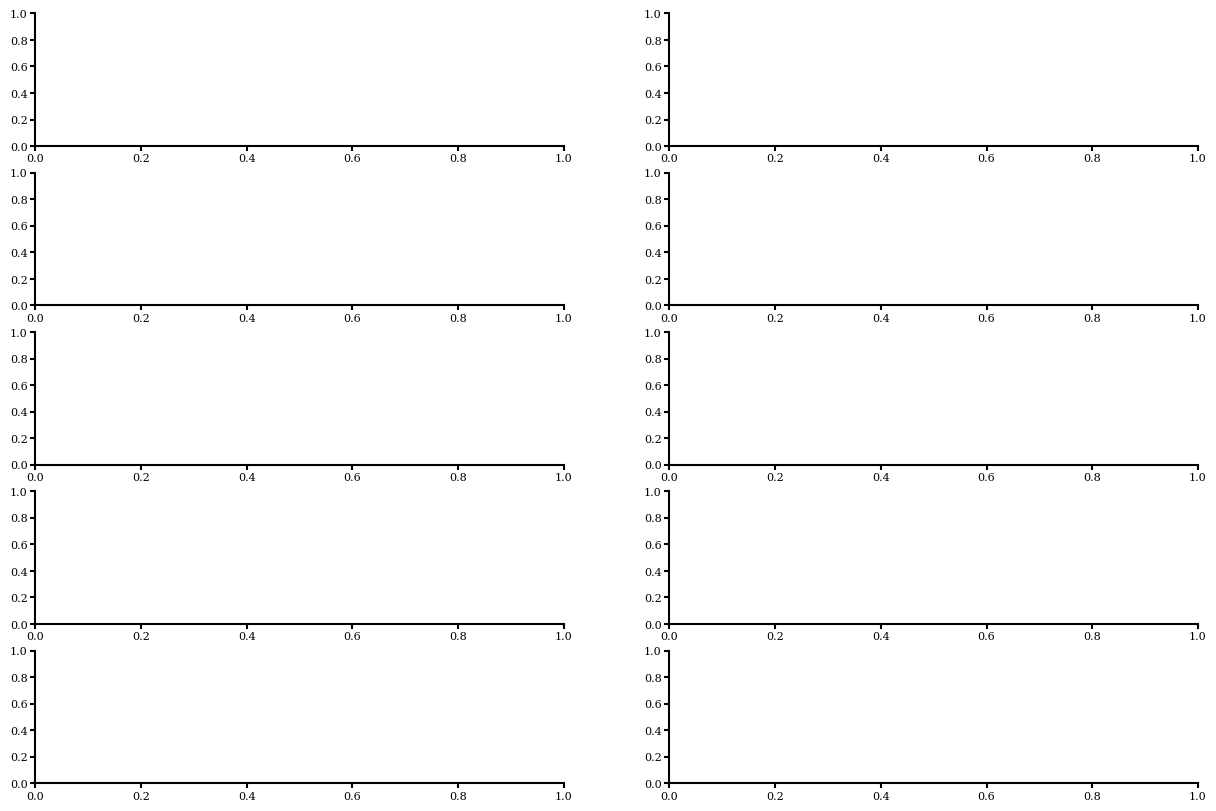

In [73]:
plot_traces(trial_trajs_gen, airpuff_trial_avgs)

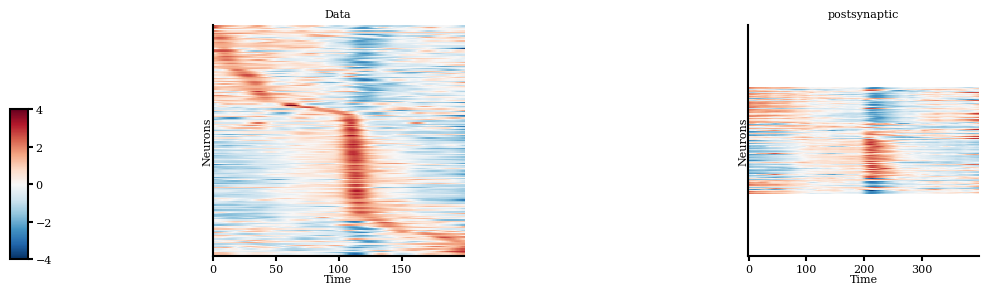

In [74]:
import matplotlib.gridspec as gridspec

fig = plt.figure(figsize=(12,3))
gs = gridspec.GridSpec(1, max(len(models),2), wspace=0.3)

ax = [fig.add_subplot(gs[0, i]) for i in range(max(len(models),2))]

mappable = ax[0].imshow(psths_val, cmap='RdBu_r', vmin=-4, vmax=4)
ax[0].set_yticks([])
ax[0].set_yticklabels([])
ax[0].set_ylabel('Neurons')
ax[0].set_xlabel('Time')
ax[0].set_title('Data')

i = 1
for model in models.keys():
    if model is 'None': continue
    neuromod = model
    avg_traj = torch.stack(trajs_gen[neuromod]).mean(axis=0)
    psth_vals, psths, nrpn, ind_1 = compute_LC_trig_activity(avg_traj, s_, dur=400)
    psths_resorted = psth_vals[np.argsort(ind_test)]
    # psths_resorted = psth_vals
    
    psths_resorted = (psths_resorted - psths_resorted.mean(axis=1, keepdims=True)) / psths_resorted.std(axis=1, keepdims=True)
    mappable2 = ax[i].imshow(psths_resorted, cmap='RdBu_r', vmin=-4, vmax=4)

    ax[i].set_yticks([])
    ax[i].set_yticklabels([])
    ax[i].set_ylabel('Neurons')
    ax[i].set_xlabel('Time')
    ax[i].set_box_aspect(1)
    # fig.colorbar(mappable1, label='intensity', shrink=0.5)
    ax[i].set_title(model)
    # break
    i += 1
plt.tight_layout()
cbar_ax = fig.add_axes([0.02, 0.1, 0.015, 0.5])  
# fig.savefig('../../results/figures/psth_neuromod_peaks.png')
fig.colorbar(mappable, cax=cbar_ax)

### Visualize and compare pairwise correlations

IndexError: list index out of range

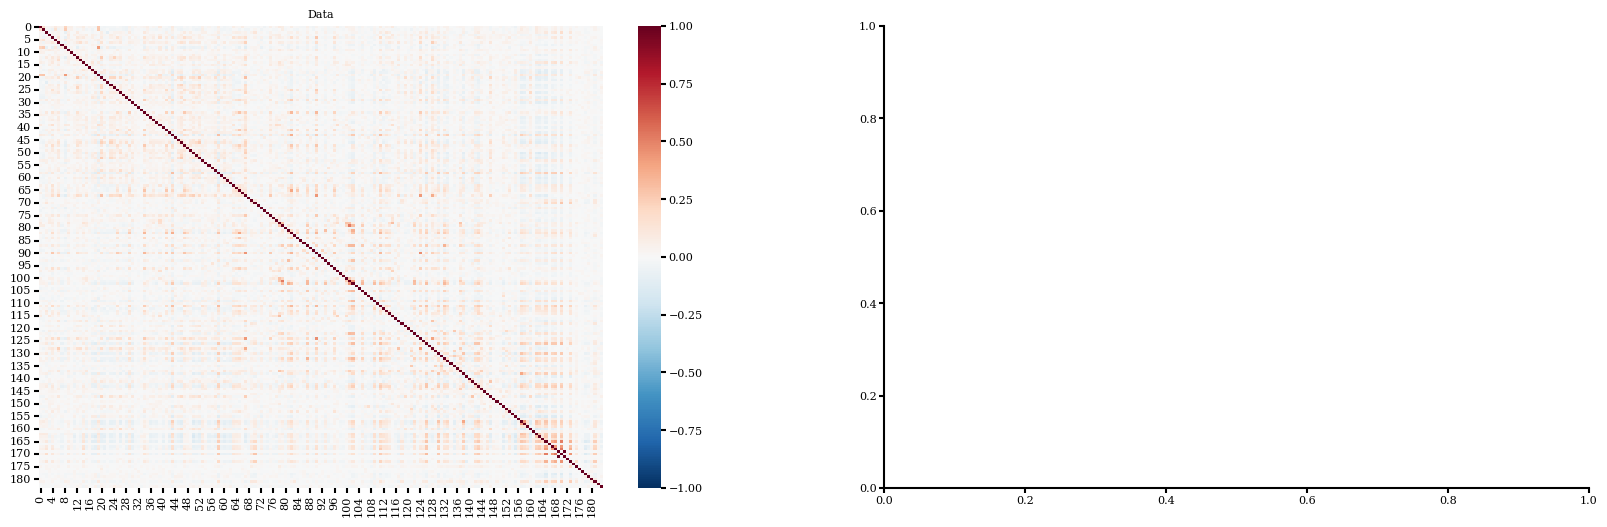

In [ ]:
fig, ax = plt.subplots(1, len(models) + 1, figsize=(20,6))

corr_test = calculate_correlation(x_.T)
corr_test = np.nan_to_num(corr_test)
sns.heatmap(corr_test, ax=ax[0], annot=False, cmap='RdBu_r', center=0, cbar=True, vmin=-1, vmax=1)
ax[0].set_title('Data')
for i in range(0, len(models)):
    corr_model = calculate_correlation(trajs_gen[neuromodulation_mechanisms[i]][10].T.numpy())
    corr_model =  np.nan_to_num(corr_model)
    r = pearsonr(corr_model.flatten(), corr_test.flatten())[0]
    sns.heatmap(corr_model, ax=ax[i+1], annot=False, cmap='RdBu_r', center=0, cbar=True, vmin=-1, vmax=1)
    ax[i+1].set_title(f'{neuromodulation_mechanisms[i]}, R = {r}')

### Look at some traces

In [ ]:
def plot_trajectory_colormap(trajs_gen, trajs_test, mechanism):
    """
    Plot the population activity as a colormap 
    Args: 
        trajs_gen (numpy.ndarray; num_neurons x time): trial-averaged generated trajectories 
        trajs_test (numpy.ndarray; num_neurons x time): trial-averaged test trajectories 
        mechanism (string): Neuromodulation mechanism
    """
    # compute the trial averaged response of the generated population 
    r = pearsonr(trajs_gen.flatten(), trajs_test.flatten())[0]
    
    t_start, t_end = 0, trajs_gen.shape[1]
    n_units = trajs_gen.shape[0]
    fig, axes = plt.subplots(
        1, 2, 
        figsize=(6, 3), 
        sharex=True  
    )
    vmin, vmax = np.percentile(trajs_test, [2, 80])

    im_top = axes[0].imshow(
        trajs_gen,
        origin='lower',         
        aspect='auto',          
        cmap='Blues',           
        extent=[t_start, t_end, 0, n_units],
        vmin=vmin,
        vmax=vmax
    )
    axes[0].set_ylabel('Units')
    axes[0].set_yticks([0, n_units/2, n_units])
    axes[0].set_yticklabels([0, int(n_units/2), n_units])
    axes[0].set_title('Generated (Postsynaptic)')
    
    axes[0].set_xlabel('Time', labelpad=5)
    vmin, vmax = np.percentile(trajs_test, [2, 80])
    im_bottom = axes[1].imshow(
        trajs_test,
        origin='lower',
        aspect='auto',
        cmap='Blues',            
        extent=[t_start, t_end, 0, n_units],
        vmin=vmin,
        vmax=vmax
    )
    axes[0].set_xticklabels([])
    axes[0].set_xticks([])
    axes[1].set_yticks([0, n_units/2, n_units])
    axes[1].set_yticklabels([0, int(n_units/2), n_units])
    axes[1].set_title('Test')
    cbar = fig.colorbar(im_bottom, label='intensity', shrink=0.5, ticks=[-0.2, -0.1, 0, 0.1, 0.2])
    
    axes[1].set_yticks([])
    fig.suptitle(f'R = {r}')
    axes[1].set_ylabel('')
    plt.tight_layout()
    plt.show()
    

In [ ]:
trial_trajs_gen.keys()

dict_keys(['postsynaptic'])

In [ ]:
plot_trajectory_colormap(trial_trajs_gen['postsynaptic'].numpy(), airpuff_trial_avgs.numpy(), 'Postsynaptic')

ValueError: x and y must have the same length.

## Evaluate state-space metrics

### Define some plotting functions

In [ ]:
def plot_bar_scatter_sem(ax, data_dict, title, y_label='KL Divergence', plot_delta=False):
    """
    Plots a bar chart (mean ± SEM) for each key in data_dict,
    overlaid with scatter points for the individual data.
    """
    keys = list(data_dict.keys())  
    n_keys = len(keys)

    # if we want to see the delta, subtract the values of the other keys from None_stim 
    if plot_delta:
        for k in keys:
            if k != 'None_stim':
                data_dict[k] = np.array(data_dict[k]) - np.array(data_dict['None_stim'])
        del data_dict['None_stim']
        keys.remove('None_stim')
        n_keys -= 1
    #Compute mean & SEM for each model
    means = []
    sems  = []
    for k in keys:
        vals = data_dict[k]
        m = np.mean(vals)
        std = np.std(vals, ddof=1)
        n = len(vals)
        sem = std / np.sqrt(n)   
        means.append(m)
        sems.append(sem)
    
    x_pos = np.arange(n_keys)  
    
    # Plot the bars with error bars
    ax.bar(x_pos, means, yerr=sems, capsize=5, alpha=0.7, color='lightcoral')
    ax.scatter(x_pos, means)
    # Plot scatter points
    scatter_positions = [[] for _ in range(n_keys)]
    
    for j, k in enumerate(keys):
        values = data_dict[k]
        n_vals = len(values)
        # random jitter in x so points don't overlap
        x_jitter = np.random.uniform(-0.05, 0.05, size=n_vals)
        for i, val in enumerate(values):
            x_i = x_pos[j] + x_jitter[i]
            y_i = val
            ax.scatter(x_i, y_i, color='black', alpha=0.6, s=20)
            scatter_positions[j].append((x_i, y_i))
    
    # Draw arrows between consecutive bars for each data index    
    for j in range(n_keys - 1):
        n_data = len(scatter_positions[j])
        for i in range(n_data):
            (x1, y1) = scatter_positions[j][i]
            (x2, y2) = scatter_positions[j+1][i]
            
            # draw an arrow from (x1, y1) to (x2, y2)
            ax.annotate(
                "", 
                xy=(x2, y2),
                xytext=(x1, y1),
                arrowprops=dict(
                    arrowstyle="->",
                    alpha=0.3,
                    color="gray",
                    lw=1.0  
                )
            )
    
    ax.set_title(title, fontsize=11)
    ax.set_xticks(x_pos)
    ax.set_xticklabels(keys, rotation=45, ha='right')
    ax.set_ylabel(y_label)


In [ ]:
def box_plot(data_dicts, figname, dict_labels=None, title="", y_label="R", y_lims=None): 
    box_spacing = 0.5
    positions = np.linspace(1, len(data_dicts) * box_spacing, len(data_dicts))
    colors = ["#000000", "#dc78fa", "#00DCDC", "#edc174", "#c9081b"]
    
    fig, axes = plt.subplots()
    
    # Define boxplot style properties
    boxprops = dict(linestyle='-', linewidth=1, facecolor='white')
    medianprops = dict(linestyle='-', linewidth=2, color='grey')
    whiskerprops = dict(linestyle='--', color='black')
    capprops = dict(linestyle='-', linewidth=1, color='black')

    #convert data dictionary to list of lists 
    stats_list = []
    for k in data_dicts.keys():
    # for k in range(len(data_dicts)):
        stats_list.append(data_dicts[k])
    
    bp1 = axes.boxplot(
        stats_list,
        patch_artist=True,
        labels=dict_labels,
        boxprops=boxprops,
        medianprops=medianprops,
        whiskerprops=whiskerprops,
        capprops=capprops,
        showfliers=False,
        widths=0.2,
        # positions=[0, 0.5, 1.0, 1.5, 2.0]
    )
    for patch, color in zip(bp1['boxes'], colors):
        patch.set_facecolor(color)

    legend_handles = [Patch(facecolor=color, label=label) for color, label in zip(colors, dict_labels)]

    fig.legend(handles=legend_handles, loc='upper left', ncol=1, bbox_to_anchor=(0.1, 1.0))
    
    axes.set_ylabel(y_label)
    if y_lims:
        axes.set_ylim(y_lims)
    axes.set_title(title)
    axes.spines['bottom'].set_visible(False)            
    axes.tick_params(axis='x', which='both', bottom=False, labelbottom=False) 
    axes.legend(loc='upper left')
    plt.tight_layout()
    plt.show()
    results_path = '../results/figures/'
    # figpath = os.path.join(results_path, figname)
    # fig.savefig(figpath, format='png')
    


In [ ]:
def plot_grouped_bars(data_dicts, figname, x_labels, dict_labels=None, title="Grouped Bar Plot", y_label="R", c=None):
    """
    Creates a grouped bar plot from dictionaries that share the same keys.
    
    For each key, we plot n bars side by side (one for each dictionary).
    The bar height is the mean of the list of values; error bars show SEM.
    """
    colors = ["#1F456E", "#000000", "#dc78fa", "#00DCDC", "#edc174", "#ed5f6d"]
    if c is not None: colors = c 
    else: colors = ["#1F456E", "#000000", "#dc78fa", "#a913d6",  "#00DCDC", "#008080", "#edc174", "#c98510",  "#ed5f6d", "#c9081b"]
    scatter_colors = ["#a913d6", "#008080", "#c98510"]
    errorbar_colors = ['#dc78fa', "#00DCDC", "#edc174"]

    keys = list(data_dicts[0].keys())
    n_keys = len(keys)
    n_dicts = len(data_dicts)  
    
    x = np.arange(n_keys)
    width = 0.1  

    fig, ax = plt.subplots(figsize=(10, 6))
    
    for i, d in enumerate(data_dicts):
        means = []
        sems  = []
        for k in keys:
            values = d[k]
            m = np.mean(values)
            std = np.std(values, ddof=1)
            n = len(values)
            sem = std / np.sqrt(n) 
            means.append(m)
            sems.append(sem)
        
        bar_x = x + i * width
        
        ax.bar(
            bar_x, 
            means, 
            yerr=sems, 
            width=width, 
            alpha=0.7, 
            # label=dict_labels[i], 
            capsize=5,
            color=colors[i]
        )
        # ax.scatter(np.arange(0, len(means)), means, color=scatter_colors[i], s=30)
        # if dict_labels is not None: 
        #     ax.errorbar(np.arange(0, len(means)), means, yerr=sems, color=errorbar_colors[i], label=dict_labels[i])
        # else:
        #     ax.errorbar(np.arange(0, len(means)), means, yerr=sems, color=errorbar_colors[i])
        # ax.plot(means, c="#000000")
    
    ax.set_xticks(x + width*(n_dicts-1)/2)
    ax.set_xticklabels(x_labels, rotation=45, ha="right")
    
    ax.set_ylabel(y_label)
    ax.set_title(title)
    ax.legend()
    plt.tight_layout()
    results_path = '../../results/figures/'
    figpath = os.path.join(results_path, figname)
    # fig.savefig(figpath)
    plt.show()
    return fig, ax 


def plot_grouped_bars_line(data_dicts, figname, x_labels, dict_labels=None, title="Grouped Bar Plot", y_label="R"):
    colors = ["#000000", "#2D3748", "#E53E3E", "#ECC94B", "#008080"]
    scatter_colors = ["#a913d6", "#008080", "#c98510"]
    errorbar_colors = ["#000000", '#dc78fa', "#00DCDC", "#edc174", "#ed5f6d"]
    # if dict_labels is not None:
    #     colors = colors[len(colors) - len(dict_labels):] 
    # elif len(data_dicts) == 4:
    #     dict_labels = ["Baseline", "White noise", "Airpuff", "Reward"]  

    keys = list(data_dicts[0].keys())
    n_keys = len(keys)
    n_dicts = len(data_dicts)  
    
    x = np.arange(n_keys)
    width = 0.1 

    fig, ax = plt.subplots(figsize=(10, 6))
    
    for i, d in enumerate(data_dicts):
        keys = list(data_dicts[i].keys())
        means = []
        sems  = []
        for k in keys:
            values = d[k]
            m = np.mean(values)
            std = np.std(values, ddof=1)
            n = len(values)
            sem = std / np.sqrt(n) 
            means.append(m)
            sems.append(sem)
        
        bar_x = x + i * width
       
        if dict_labels is not None: 
            ax.errorbar(np.arange(0, len(means)), means, yerr=sems, color=errorbar_colors[i], label=dict_labels[i])
        else:
            ax.errorbar(np.arange(0, len(means)), means, yerr=sems, color=errorbar_colors[i])
        
    # Center x-ticks among the group of bars:
    ax.set_xticks(x + width*(n_dicts-1)/2)
    ax.set_xticklabels(x_labels, rotation=45, ha="right")
    ax.set_xlabel('Rank')
    ax.set_ylabel(y_label)
    ax.set_title(title)
    ax.legend(loc='lower right')
    plt.tight_layout()
    results_path = '../results/figures/'
    figpath = os.path.join(results_path, figname)
    fig.savefig(figpath, format='svg')
    # plt.show()
    return fig, ax 

def compute_offsets(n_keys, width, gap, extra_spacing):
    offsets = [0]
    for j in range(1, n_keys):
        extra = gap
        if extra_spacing:
            extra = gap if ((j - 1) % 2 == 0) else 0
        offsets.append(offsets[j-1] + width + extra)
    offsets = np.array(offsets)
    offsets = offsets - np.mean(offsets)
    return offsets

def plot_grouped_bars_by_dict(data_dicts, dict_labels=None,
                              title="Grouped Bar Plot", x_labels=None,
                              y_label="Value", keys=None, figname=None, c=None, extra_spacing=True):
    """
    This function creates a grouped bar plot where each dictionary
    is one "group" on the x-axis, and each key in the dictionaries
    is a sub-bar within that group.
    """
    if c is not None: colors = c
    else: colors = ["#000000", "#a913d6", "#008080",  "#c98510",  "#c9081b", "#1F456E"]
    
    # If no labels are provided for the dictionaries, make generic ones
    if dict_labels is None:
        dict_labels = [f"Dict {i+1}" for i in range(len(data_dicts))]

    keys = list(data_dicts[0].keys())
    n_dicts = len(data_dicts)
    n_keys = len(keys)

    x = np.arange(n_dicts)  
    width = 0.5 / n_keys  

    fig, ax = plt.subplots(figsize=(5,5))

    offsets = compute_offsets(n_keys, width, gap=0.01, extra_spacing=extra_spacing)

    group_x = np.arange(n_dicts)
    
    for j, k in enumerate(keys):
        means = []
        sems = []
        for d in data_dicts:
            vals = d[k]
            m = np.mean(vals)
            s = np.std(vals, ddof=1)      
            n = len(vals)
            sem = s / np.sqrt(n)          
            means.append(m)
            sems.append(sem)

        bar_x = group_x + offsets[j]
    
        ax.bar(
            bar_x, 
            means,
            yerr=sems,
            width=width,
            alpha=0.7,
            color=colors[j],
            label=dict_labels[j]  # legend label is the key
        )

    # Cosmetic details
    ax.set_xticks(x)
    ax.set_xticklabels(x_labels, rotation=45, ha='right')
    ax.set_ylabel(y_label)
    ax.set_title(title) # or just ax.legend()

    plt.tight_layout()
    plt.legend()
    results_path = '../results/'
    figpath = os.path.join(results_path, figname)
    # fig.savefig(figpath)
    plt.show()

def plot_scatter(r_vals, title, figname):
    models = ['postsynaptic', 'presynaptic', 'additive', 'rank']
    colors = ["#a913d6",  "#008080", "#c98510", "#c9081b"]
    markers = ['X', 'o', '*', '+']
    # first compute the average for the Non-modulated model 
    stim_only_avg = np.array(r_vals['None_stim']).mean()
    # compute the average for the additive only modulated model 
    additive_avg = np.array(r_vals['additive']).mean()
    postsynaptic_avg = np.array(r_vals['postsynaptic']).mean()
    presynaptic_avg = np.array(r_vals['presynaptic']).mean()
    rank_avg = np.array(r_vals['rank']).mean() 
    
    fig, ax = plt.subplots()
    for i, model in enumerate(models):
        ax.scatter(r_vals[model], r_vals[f'{model}_stim'], c=colors[i], marker=markers[i], s=15, label=models[i])
    ax.axhline(stim_only_avg, linestyle='--', c='black', label='Stimuli only')
    # ax.axvline(additive_avg, linestyle='--', c='#c98510', alpha=0.5)
    # ax.axvline(postsynaptic_avg, linestyle='--', c="#a913d6", alpha=0.5)
    # ax.axvline(presynaptic_avg, linestyle='--', c="#008080", alpha=0.5)
    # ax.axvline(rank_avg, linestyle='--', c='#c9081b', label='Rank', alpha=0.5)
    
    ax.set_xlabel('Neuromodulator only')
    ax.set_ylabel('Neuromodulator+Stimuli')
    ax.set_xlim([0, 1])
    ax.set_ylim([0, 1])
    ax.legend()
    fig.suptitle(title)

    ax.plot([[0, 0], [1, 1]], c='grey', alpha=0.5, linestyle='--')
    # results_path = '../../results/'
    # plt.tight_layout()
    # figpath = os.path.join(results_path, figname)
    # fig.savefig(figpath)
    # plt.show()

In [ ]:
def load_stats(model_configs, eval_dataset='nk341_mPFC'):
    kl_divs = {c["name"]: [] for c in model_configs}
    sliced_was_dists = {c["name"]: [] for c in model_configs}
    was_dists = {c["name"]: [] for c in model_configs}
    mres = {c["name"]: [] for c in model_configs}
    white_noise_r_vals = {c["name"]: [] for c in model_configs}
    airpuff_r_vals = {c["name"]: [] for c in model_configs}
    reward_r_vals = {c["name"]: [] for c in model_configs}

    for seed in range(1):
        for c in model_configs: 
            # stat_dict_path = f'{eval_dataset}_{c["neuromodulation"]}_rank_{c["rank"]}_activation_{c["activation"]}_seed_{seed}_stim_{c["stim"]}_binsize_{str(c["bin_size"]).replace(".", "_")}_daleslaw_{c["dales_law"]}/stat_dict.pkl'
            stat_dict_path = f'{eval_dataset}_{c["neuromodulation"]}_rank_{c["rank"]}_activation_{c["activation"]}_seed_{seed}_stim_{c["stim"]}_binsize_{str(c["bin_size"]).replace(".", "_")}_daleslaw_{c["dales_law"]}/stat_dict.pkl'
            
            file_path = os.path.join(config["stat_dir"], stat_dict_path)
            with open(file_path, 'rb') as f: 
                stat_dict = pickle.load(f)
                kl_divs[c["name"]].append(np.median(stat_dict['kl divs']))
                # kl_divs[c["name"]] += stat_dict['kl divs']
                sliced_was_dists[c["name"]].append(np.median(stat_dict['sliced wasserstein']))
                was_dists[c["name"]].append(np.median(stat_dict['wasserstein']))

                mres[c["name"]].append(np.mean(stat_dict['mres']))
                white_noise_r_vals[c["name"]].append(np.median(stat_dict['R white noise']))
                airpuff_r_vals[c["name"]].append(np.median(stat_dict['R airpuff']))
                reward_r_vals[c["name"]].append(np.median(stat_dict['R reward']))

    # append data stats 
    # kl_divs['data'] = kl_divs_data
    # was_dists['data'] = was_dists_data
    # mres['data'] = mres_data          
    return kl_divs, was_dists, sliced_was_dists, mres, white_noise_r_vals, airpuff_r_vals, reward_r_vals

## Compare mechanisms across ranks

### We load the stats and save them in a dictionary for plotting

In [ ]:
eval_dataset = "nk339_mPFC"

kl_div_res = {} 
was_dist_res = {} 
sliced_was_dist_res = {}
mres_res = {} 
white_noise_r_vals_res = {} 
airpuff_r_vals_res = {} 
reward_r_vals_res = {}

for mechanism in neuromodulation_mechanisms:
    rank_kl_divs, rank_was_dists, rank_sliced_was_dists, rank_mres, rank_white_noise_r_vals, rank_airpuff_r_vals, rank_reward_r_vals = {}, {}, {}, {}, {}, {}, {}
    for r in [4]:#range(1, 11): 
        k = f'rank-{r}' 
        model_config = [
            {
                "name": mechanism, 
                "neuromodulation": mechanism, 
                "stim": True, 
                "rank": r, 
                "dales_law": False, 
                "activation": "clipped_relu",
                "bin_size": 0.05
            }
        ]
        kl_divs, was_dists, sliced_wasserstein_distance, mres, white_noise_r_vals, airpuff_r_vals, reward_r_vals = load_stats(model_config, eval_dataset)
        rank_kl_divs[k] = kl_divs[mechanism]
        rank_was_dists[k] = was_dists[mechanism]
        rank_sliced_was_dists[k] = sliced_wasserstein_distance[mechanism]
        rank_mres[k] = mres[mechanism]
        rank_white_noise_r_vals[k] = white_noise_r_vals[mechanism]
        rank_airpuff_r_vals[k] = airpuff_r_vals[mechanism]
        rank_reward_r_vals[k] = reward_r_vals[mechanism] 

    kl_div_res[mechanism] = rank_kl_divs
    was_dist_res[mechanism] = rank_was_dists 
    sliced_was_dist_res[mechanism] = rank_sliced_was_dists
    mres_res[mechanism] = rank_mres
    white_noise_r_vals_res[mechanism] = rank_white_noise_r_vals
    airpuff_r_vals[mechanism] = rank_airpuff_r_vals
    reward_r_vals[mechanism] = rank_reward_r_vals 


In [ ]:
kl_div_res

{'postsynaptic': {'rank-4': [0.9147803783416748]}}

In [ ]:
#nk339_mPFC_postsynaptic_rank_4_activation_clipped_relu_seed_0_stim_True_binsize_0_05_daleslaw_False


In [ ]:
kl_divs_arr = [kl_div_res['None'], kl_div_res['postsynaptic'], kl_div_res['presynaptic'], kl_div_res['additive'], kl_div_res['rank']]
labels = ['None', 'Postsynaptic', 'Presynaptic', 'Additive', 'Rank']
fig, ax = plot_grouped_bars_line(kl_divs_arr, 'kl_divs_model_and_data.svg', title="", x_labels=np.arange(1, 11), y_label="KL-Divergence", dict_labels=labels)
ax.axhline(np.median(kl_divs_data), linestyle='--', label='Train vs Test')
plt.legend()
plt.show()

KeyError: 'None'

In [ ]:
was_dists_arr = [was_dist_res['None'], was_dist_res['postsynaptic'], was_dist_res['presynaptic'], was_dist_res['additive'], was_dist_res['rank']]
fig, ax = plot_grouped_bars_line(was_dists_arr, 'temp.svg', title="", x_labels=np.arange(1, 11), y_label="KL-Divergence", dict_labels=labels)
ax.axhline(np.median(was_dists_data), linestyle='--', label='Train vs Test')
plt.legend()
plt.show()

KeyError: 'None'

In [ ]:
mres_arr = [mres_res['None'], mres_res['postsynaptic'], mres_res['presynaptic'], mres_res['additive'], mres_res['rank']]
fig, ax = plot_grouped_bars_line(mres_arr, 'temp.svg', title="", x_labels=np.arange(1, 11), y_label="KL-Divergence", dict_labels=labels)
ax.axhline(np.median(mres_data), linestyle='--', label='Train vs Test')
plt.legend()
plt.show()

KeyError: 'None'

### Load stats of models with and without stimuli to compare trial averaged responses

In [ ]:
neuromodulation_mechanisms = ["None", "postsynaptic", "presynaptic", "additive", "rank"]
models = {}

white_noise_r_vals_res = {} 
airpuff_r_vals_res = {} 
reward_r_vals_res = {}

for neuromodulation in neuromodulation_mechanisms:

    for stim in [True, False]:
        model_config = [{
            "name": neuromodulation, 
            "neuromodulation": neuromodulation, 
            "stim": stim, 
            "rank": 3, 
            "dales_law": False, 
            "activation": "clipped_relu",
            "bin_size": 0.05
        }]
        kl_divs, was_dists, sliced_wasserstein_distance, mres, white_noise_r_vals, airpuff_r_vals, reward_r_vals = load_stats(model_config, eval_dataset)
        if neuromodulation == 'None' and stim == False: print('adding')
        if stim: 
            white_noise_r_vals_res[f'{neuromodulation}_stim'] = white_noise_r_vals[neuromodulation]
            airpuff_r_vals_res[f'{neuromodulation}_stim'] = airpuff_r_vals[neuromodulation]
            reward_r_vals_res[f'{neuromodulation}_stim'] = reward_r_vals[neuromodulation] 
        else: 
            white_noise_r_vals_res[neuromodulation] = white_noise_r_vals[neuromodulation]
            airpuff_r_vals_res[neuromodulation] = airpuff_r_vals[neuromodulation]
            reward_r_vals_res[neuromodulation] = reward_r_vals[neuromodulation] 

FileNotFoundError: [Errno 2] No such file or directory: '../results/model_evals/nk339_mPFC_None_rank_3_activation_clipped_relu_seed_0_stim_True_binsize_0_05_daleslaw_False/stat_dict.pkl'

In [ ]:
plot_scatter(airpuff_r_vals_res, '', '')

KeyError: 'None_stim'

In [ ]:
plot_scatter(reward_r_vals_res, '', '')

KeyError: 'None_stim'

In [ ]:
plot_scatter(white_noise_r_vals_res, '', '')

KeyError: 'None_stim'